<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Rebeca MG\AppData\Local\Temp\ipykernel_18780\2081378088.py:6: SyntaxWarning: invalid escape sequence '\o'
  img1 = cv2.imread('img\objeto.jpg', 0)  # Imagen del objeto
C:\Users\Rebeca MG\AppData\Local\Temp\ipykernel_18780\2081378088.py:7: SyntaxWarning: invalid escape sequence '\e'
  img2 = cv2.imread('img\escena.jpg', 0)  # Imagen de la escena


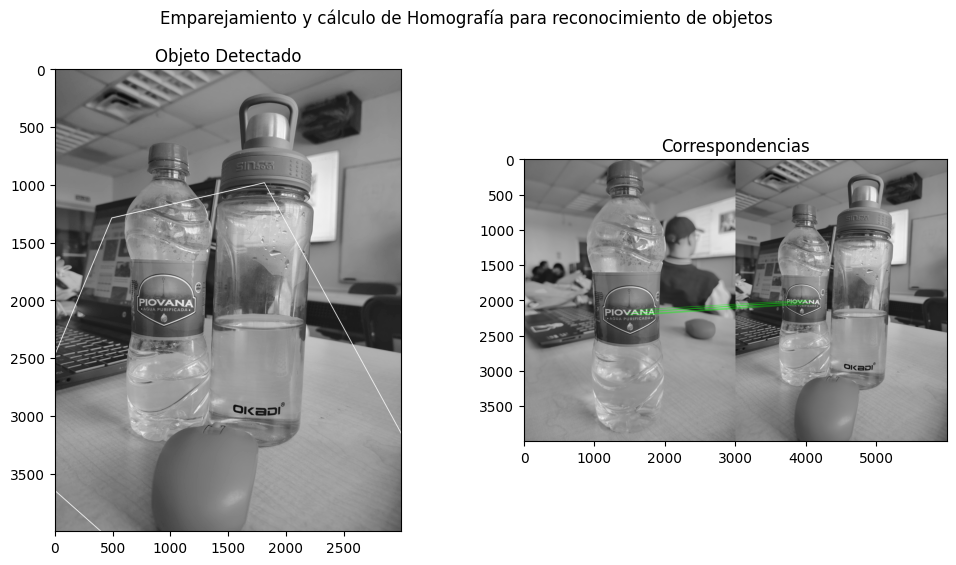

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar las imágenes
img1 = cv2.imread('img\objeto.jpg', 0)  # Imagen del objeto
img2 = cv2.imread('img\escena.jpg', 0)  # Imagen de la escena

# Detectar características y calcular descriptores usando ORB
orb = cv2.ORB_create()
keypoints1, descriptors1 = orb.detectAndCompute(img1, None)
keypoints2, descriptors2 = orb.detectAndCompute(img2, None)

# Matcher para encontrar correspondencias
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)

# Ordenar las correspondencias por distancia
matches = sorted(matches, key=lambda x: x.distance)

# Extraer puntos clave
pts_src = np.float32([keypoints1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
pts_dst = np.float32([keypoints2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

# Encontrar la matriz de homografía
M, mask = cv2.findHomography(pts_src, pts_dst, cv2.RANSAC, 5.0)

# Usar la matriz para obtener las esquinas del objeto detectado en la escena
h, w = img1.shape
pts_corners_src = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
pts_corners_dst = cv2.perspectiveTransform(pts_corners_src, M)
# Dibujar el contorno del objeto en la imagen de la escena con un color más visible y mayor grosor
img2_with_contour = cv2.polylines(img2.copy(), [np.int32(pts_corners_dst)], True, (255, 0, 0), 5)

# Mostrar correspondencias usando drawMatches, aumentando el grosor de las líneas
img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:20], None, matchColor=(0, 255, 0), singlePointColor=(255, 0, 0), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Mostrar resultados
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img2_with_contour, cmap='gray')
plt.title('Objeto Detectado')

plt.subplot(1, 2, 2)
plt.imshow(img_matches)
plt.title('Correspondencias')

plt.suptitle('Emparejamiento y cálculo de Homografía para reconocimiento de objetos')
plt.show()

In [3]:
import cv2
import os
import pickle
import numpy as np

OVERLAY_SIZE_PER = 1

# Check for camera calibration data
if not os.path.exists('./calibration.pckl'):
    print("You need to calibrate the camera before")
    exit()
else:
    with open('calibration.pckl', 'rb') as f:
        cameraMatrix, distCoeffs = pickle.load(f)
    if cameraMatrix is None or distCoeffs is None:
        print("Something went wrong. Recalibrate the camera")
        exit()

# Load the image overlay
overlay = cv2.imread("tree_overlay.png")

def draw_augmented_overlay(pts_1, overlay_image, image):
    """Overlay the image 'overlay_image' onto the image 'image'"""
    pts_2 = np.float32([[0, 0], [overlay_image.shape[1], 0], 
                        [overlay_image.shape[1], overlay_image.shape[0]], [0, overlay_image.shape[0]]])

    M = cv2.getPerspectiveTransform(pts_2, pts_1)
    dst_image = cv2.warpPerspective(overlay_image, M, (image.shape[1], image.shape[0]))
    
    dst_image_gray = cv2.cvtColor(dst_image, cv2.COLOR_BGR2GRAY)
    ret, mask = cv2.threshold(dst_image_gray, 0, 255, cv2.THRESH_BINARY_INV)
    image_masked = cv2.bitwise_and(image, image, mask=mask)

    result = cv2.add(dst_image, image_masked)
    return result

# Create the dictionary object and the detector
dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_7X7_250)
parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(dictionary, parameters)

# Create video capture object
capture = cv2.VideoCapture(0)

while True:
    ret, frame = capture.read()
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect markers
    corners, ids, _ = detector.detectMarkers(gray_frame)

    # Draw detected markers
    frame = cv2.aruco.drawDetectedMarkers(frame, corners, ids)

    if ids is not None:
        rvecs, tvecs, _ = cv2.aruco.estimatePoseSingleMarkers(corners, 1, cameraMatrix, distCoeffs)

        for i in range(len(ids)):
            # Project the points
            desired_points = np.float32([[-1 / 2, 1 / 2, 0], [1 / 2, 1 / 2, 0], [1 / 2, -1 / 2, 0], [-1 / 2, -1 / 2, 0]]) * OVERLAY_SIZE_PER
            projected_desired_points, _ = cv2.projectPoints(desired_points, rvecs[i], tvecs[i], cameraMatrix, distCoeffs)

            # Overlay the image on the marker
            frame = draw_augmented_overlay(projected_desired_points, overlay, frame)

    # Display the resulting augmented frame
    cv2.imshow('frame', frame)

    # Press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release everything
capture.release()
cv2.destroyAllWindows()

AttributeError: 'NoneType' object has no attribute 'shape'